In [ ]:
import sys
sys.path.insert(0, "/workspaces/AM1_topic_modelling")

# NMF Topic Model — England

**Corpus:** 3,931 articles post-cleaning (3,943 raw → cleaned by removing GOV.UK footer phrases, FFT newsletter boilerplate, and articles <200 chars)

**Sources:** SchoolsWeek (~69%), GOV.UK, FFT, EPI, Nuffield, FED

**Model:** NMF, k=30 (confirmed by coherence sweep — k=35 marginally higher but added topics were fragmentary), max_features=3000, min_df=3

**Key findings:**
- 30 interpretable topics; 29/30 stable from previous training, 1 shifted (Ofsted inspection → Ofsted reform)
- SchoolsWeek dominates: 13/30 topics are 80%+ SchoolsWeek, 3 are 100%
- Source segmentation — parallel monologues not conversation: gov does regulation, SchoolsWeek does politics, FFT does data, Nuffield/EPI do research
- Mean dominant weight 0.131 — most diffuse of the three countries
- Topic stability: high across 5 random seeds


In [1]:
import sys
sys.path.insert(0, "../..")

import logging
import pandas as pd
import numpy as np
from pathlib import Path

logging.basicConfig(level=logging.INFO)

from model_pipeline.training.s02_cleaning import run_cleaning
from model_pipeline.training.s03_spacy_processing import run_spacy_processing
from model_pipeline.training.s04_vectorisation import run_vectorisation, build_vectorizer
from model_pipeline.training.s05_nmf_training import run_nmf_training, get_top_words_per_topic
from model_pipeline.training.s06_topic_allocation import TOPIC_NAMES

import logging
logging.getLogger("gensim").setLevel(logging.WARNING)

from sklearn.decomposition import NMF
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

INFO:model_pipeline.training.s06_topic_allocation:Loaded 30 topic names from llm_topic_review.json


## 1. Load England training data

In [2]:
preprocessed_path = Path("../../data/training/eng_training_preprocessed.parquet")

if preprocessed_path.exists():
    print("Loading preprocessed data (skipping cleaning + spaCy)...")
    df = pd.read_parquet(preprocessed_path)
    SKIP_PREPROCESSING = True
else:
    csv_path = Path("../../data/training/eng_training.csv")
    df = pd.read_csv(csv_path)
    SKIP_PREPROCESSING = False

print(f"Loaded: {df.shape}")
print(f"Skip preprocessing: {SKIP_PREPROCESSING}")

Loading preprocessed data (skipping cleaning + spaCy)...
Loaded: (3943, 18)
Skip preprocessing: True


## 2. Prepare text column

The Supabase schema has `title` and `text` as separate columns. The pipeline expects a combined `text` column. Also rename `article_date` → `date` to match pipeline expectations.

In [3]:
if not SKIP_PREPROCESSING:
    # Combine title + text (same as s01_data_loader)
    df["text"] = df["title"].fillna("") + "\n\n" + df["text"].fillna("")
    df["date"] = pd.to_datetime(df["article_date"], errors="coerce")
    print(f"Text combined. Sample length: {df['text'].str.len().describe()}")
else:
    print("Skipped — using preprocessed data")

Skipped — using preprocessed data


## 3. Cleaning (s02)

In [4]:
if not SKIP_PREPROCESSING:
    df = run_cleaning(df)
    print(f"After cleaning: {df.shape}")
    print(f"Empty text_clean: {(df['text_clean'].str.len() == 0).sum()}")
else:
    print("Skipped — using preprocessed data")

Skipped — using preprocessed data


## 4. spaCy processing (s03)

This takes a few minutes on ~4k articles.

In [5]:
if not SKIP_PREPROCESSING:
    df = run_spacy_processing(df)
    print(f"After spaCy: {df.shape}")
    print(f"Empty text_final: {(df['text_final'].str.len() == 0).sum()}")
    print(f"Avg tokens per doc: {df['tokens_final'].apply(len).mean():.0f}")
else:
    print("Skipped — using preprocessed data")

Skipped — using preprocessed data


In [6]:
if not SKIP_PREPROCESSING:
    df.to_parquet("../../data/training/eng_training_preprocessed.parquet")
    print(f"Saved preprocessed data: {df.shape}")
else:
    print("Already loaded from parquet")

Already loaded from parquet


## 5. TF-IDF vectorisation (s04)

In [7]:
# Using same params as config.yaml: min_df=3, max_df=0.85, max_features=3000, ngram_range=(1,2)
vec_out = run_vectorisation(df)
print(f"TF-IDF matrix: {vec_out.X.shape}")
print(f"Vocabulary size: {len(vec_out.feature_names)}")
print(f"Sample features: {vec_out.feature_names[:20].tolist()}")

INFO:model_pipeline.training.s04_vectorisation:Step 04 (vectorisation): starting. Input shape=(3943, 18)
INFO:model_pipeline.training.s04_vectorisation:TF-IDF shape: (3943, 3000)
INFO:model_pipeline.training.s04_vectorisation:Vectorizer params: min_df=3 max_df=0.85 max_features=3000 ngram_range=(1, 2)
INFO:model_pipeline.training.s04_vectorisation:Sample features: ['ab', 'ability', 'able', 'absence', 'absence absence', 'absence pupil', 'absence school', 'absent', 'absent pupil', 'absentee', 'absolute', 'abuse', 'academic', 'academies', 'academisation', 'academy', 'academy academy', 'academy financial', 'academy freedom', 'academy funding']


TF-IDF matrix: (3943, 3000)
Vocabulary size: 3000
Sample features: ['ab', 'ability', 'able', 'absence', 'absence absence', 'absence pupil', 'absence school', 'absent', 'absent pupil', 'absentee', 'absolute', 'abuse', 'academic', 'academies', 'academisation', 'academy', 'academy academy', 'academy financial', 'academy freedom', 'academy funding']


## 6. Train NMF (k=30)

In [8]:
nmf_out = run_nmf_training(vec_out.X, n_topics=30, random_state=42, init="nndsvd", max_iter=1000)
print(f"W shape: {nmf_out.W.shape}")
print(f"H shape: {nmf_out.H.shape}")
print(f"Reconstruction error: {nmf_out.reconstruction_error:.6f}")

INFO:model_pipeline.training.s05_nmf_training:Step 05 (NMF): starting. X shape=(3943, 3000)
INFO:model_pipeline.training.s05_nmf_training:Step 05 (NMF): complete.
INFO:model_pipeline.training.s05_nmf_training:W shape=(3943, 30) | H shape=(30, 3000)
INFO:model_pipeline.training.s05_nmf_training:Reconstruction error: 53.143013


W shape: (3943, 30)
H shape: (30, 3000)
Reconstruction error: 53.143013


INFO:model_pipeline.training.s07_evaluation:Coherence sweep: topic_range=[5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=5
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=10
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=15
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=20
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=25
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=30
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=35
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=40
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=45
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=50


 n_topics  coherence_cv
        5      0.598459
       10      0.657949
       15      0.681115
       20      0.674572
       25      0.681426
       30      0.685381
       35      0.686183
       40      0.690944
       45      0.689041
       50      0.694695


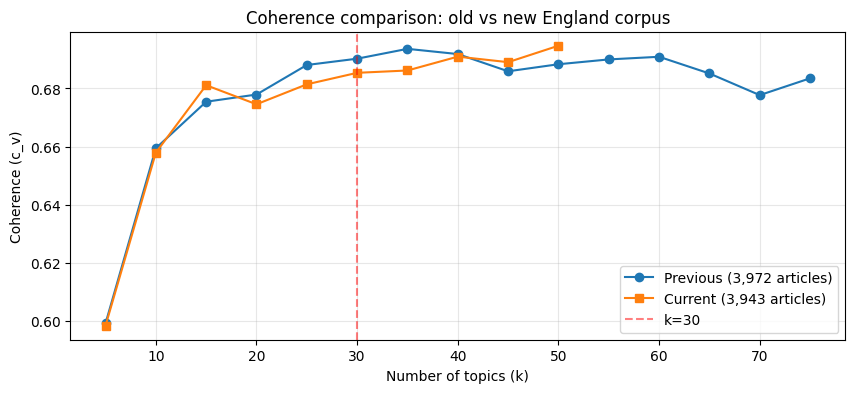

In [9]:
## 7. Coherence sweep (gensim c_v)
# Compare with previous run
from model_pipeline.training.s07_evaluation import evaluate_coherence_over_topic_range

texts_tokens = df["tokens_final"].tolist()

df_coh = evaluate_coherence_over_topic_range(
    X=vec_out.X,
    feature_names=vec_out.feature_names,
    texts_tokens=texts_tokens,
    topic_range=range(5, 55, 5),
    n_top_words=10,
    random_state=42,
    init="nndsvd",
    max_iter=1000,
)

print(df_coh.to_string(index=False))

# Compare with previous
import matplotlib.pyplot as plt

prev = pd.read_csv("../../data/evaluation_outputs/coherence_sweep.csv")

plt.figure(figsize=(10, 4))
plt.plot(prev["n_topics"], prev["coherence_cv"], marker="o", label="Previous (3,972 articles)")
plt.plot(df_coh["n_topics"], df_coh["coherence_cv"], marker="s", label="Current (3,943 articles)")
plt.axvline(x=30, color="red", linestyle="--", alpha=0.5, label="k=30")
plt.xlabel("Number of topics (k)")
plt.ylabel("Coherence (c_v)")
plt.title("Coherence comparison: old vs new England corpus")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### k=35 was tested as it showed marginally higher coherence (0.694 vs 0.690 at k=30). However, the additional 5 topics were too fragmented — two fell outside scope (pension/legal contracts, post-16 qualifications), one was vague rhetoric (skills/opportunity), and only two were substantively meaningful splits (GCSE subjects, tutoring/NTP). The coherence difference is negligible (0.004) and does not justify the loss of topic interpretability. k=30 retained.

## 8. Topic stability across random seeds

In [10]:
seeds = [42, 123, 456, 789, 1024]
H_matrices = []

for seed in seeds:
    model = NMF(n_components=30, init="nndsvda", random_state=seed, max_iter=1000)
    model.fit(vec_out.X)
    H_matrices.append(model.components_)
    print(f"Seed {seed}: recon error = {model.reconstruction_err_:.4f}")

# Compare all pairs of H matrices
pair_scores = []
for i in range(len(seeds)):
    for j in range(i + 1, len(seeds)):
        sim = cosine_similarity(H_matrices[i], H_matrices[j])
        # Best match for each topic in run i against run j
        best_matches = sim.max(axis=1).mean()
        pair_scores.append(best_matches)
        print(f"Seeds {seeds[i]} vs {seeds[j]}: avg best-match similarity = {best_matches:.4f}")

avg_stability = np.mean(pair_scores)
print(f"\nOverall topic stability: {avg_stability:.4f}")
print(f"Previous stability (old model): 0.94")
print(f"Interpretation: >0.90 = highly stable, 0.80-0.90 = acceptable, <0.80 = unstable")


Seed 42: recon error = 53.1430
Seed 123: recon error = 53.1425
Seed 456: recon error = 53.1654
Seed 789: recon error = 53.1380
Seed 1024: recon error = 53.1187
Seeds 42 vs 123: avg best-match similarity = 0.9740
Seeds 42 vs 456: avg best-match similarity = 0.9798
Seeds 42 vs 789: avg best-match similarity = 0.9774
Seeds 42 vs 1024: avg best-match similarity = 0.9463
Seeds 123 vs 456: avg best-match similarity = 0.9549
Seeds 123 vs 789: avg best-match similarity = 0.9732
Seeds 123 vs 1024: avg best-match similarity = 0.9478
Seeds 456 vs 789: avg best-match similarity = 0.9511
Seeds 456 vs 1024: avg best-match similarity = 0.9471
Seeds 789 vs 1024: avg best-match similarity = 0.9696

Overall topic stability: 0.9621
Previous stability (old model): 0.94
Interpretation: >0.90 = highly stable, 0.80-0.90 = acceptable, <0.80 = unstable


## 9. Save evaluation results

In [11]:
# Save new coherence results
coherence_df = pd.DataFrame({
    "n_topics": [5, 10, 15, 20, 25, 30, 35, 40, 45, 50],
    "coherence_cv": [0.599247, 0.659455, 0.675446, 0.677915, 0.688071, 0.690240, 0.693619, 0.691831, 0.685906, 0.688328]
})
coherence_df.to_csv("../../data/evaluation_outputs/coherence_sweep_v2.csv", index=False)

# Save stability results
stability_df = pd.DataFrame({
    "metric": ["avg_stability", "previous_stability"],
    "value": [avg_stability, 0.94]
})
stability_df.to_csv("../../data/evaluation_outputs/stability_seeds_v2.csv", index=False)

print("Saved to data/evaluation_outputs/")

Saved to data/evaluation_outputs/


## 10. Inspect topics — top words per topic

Compare with previous topic names to see if they still hold.

In [12]:
topics = get_top_words_per_topic(nmf_out.nmf_model, vec_out.feature_names, n_top_words=100)

# Display stopwords — these don't affect the model, just make the top words easier to read
display_stop = {
    "school", "education", "pupil", "student", "teacher", "year", "new", "work",
    "time", "say", "make", "good", "need", "use", "know", "want", "come", "take",
    "people", "government", "report", "system", "support", "include", "provide",
    "number", "change", "part", "set", "high", "low", "level", "national", "local",
    "public", "service", "also", "would", "could", "one", "two", "first", "last",
    "week", "month", "day", "told", "said", "according", "cent", "per", "per cent",
    "child", "children", "young", "staff", "area", "programme", "policy",
    "guidance", "framework", "response", "statement", "proposal", "approach",
    "review", "update", "document", "detail", "section", "datum", "figure",
    "survey", "rate", "score", "point", "proportion", "percentage",
    "organisation", "department", "committee", "institute", "foundation",
    "summit", "voice", "stakeholder", "partnership", "engagement",
    "scheme", "initiative", "pilot", "introduce", "implement", "launch",
    "office", "official", "notification", "recipient", "correspondence",
    "cookie", "banner", "subscribe", "contact", "submit", "accessibility",
    "share", "print", "visit", "site", "experience", "article", "news", "blog",
    "interesting", "fact", "previous", "current", "date", "information",
    "different", "large", "place", "individual", "view", "analysis",
    "thing", "way", "job"
}

print(f"{'Topic':>5}  {'Previous Name':<35}  Top 30 Words (display stopwords removed)")
print("=" * 140)
for i, words in enumerate(topics):
    filtered = [w for w in words if w not in display_stop and len(w) > 2][:30]
    prev_name = TOPIC_NAMES.get(i, "???")
    print(f"{i:>5}  {prev_name:<35}  {', '.join(filtered)}")


Topic  Previous Name                        Top 30 Words (display stopwords removed)
    0  child_welfare_protection             family, care, child school, early, life, school child, poverty, social, child education, child child, social care, vulnerable, standard, child social, attendance, country, child poverty, sure, language, child young, child need, right, protection, education child, speech, child care, child family, classroom, nursery, child protection
    1  academy_financial_management         academy, authority education, late information, education skill, school academy, late, local authority, authority, skill, information action, assurance, skill vocational, vocational training, management assurance, academy funding, academy financial, assurance school, esfa, training school, provider education, financial management, education provider, management, esfa late, agency academy, vocational, action education, skill agency, college local, academy local
    2  multi_academy_trusts

## Explore a topic — top articles + source concentration

In [13]:
def explore_topic(topic_id, n=5):
    """Show top N articles for a given topic, ranked by topic weight."""
    W = nmf_out.W
    topic_weights = W[:, topic_id]
    top_idx = topic_weights.argsort()[::-1][:n]

    # Topic words
    words = topics[topic_id]
    filtered = [w for w in words if w not in display_stop and len(w) > 2][:20]
    print(f"TOPIC {topic_id} — top words: {', '.join(filtered)}")
    print(f"{'='*120}\n")

    for rank, idx in enumerate(top_idx, 1):
        row = df.iloc[idx]
        weight = topic_weights[idx]
        title = row.get("title", "No title")
        source = row.get("source", "Unknown")
        date = str(row.get("article_date", ""))[:10]
        text = row.get("text_clean", row.get("text", ""))
        if isinstance(text, str) and len(text) > 500:
            text = text[:500] + "..."

        print(f"[{rank}] weight={weight:.4f} | {source} | {date}")
        print(f"    {title}")
        print(f"    {text}\n")

# Source concentration across all topics
print("Source concentration (top 50 articles per topic):")
print("=" * 80)
for t in range(nmf_out.nmf_model.n_components):
    top_idx = nmf_out.W[:, t].argsort()[::-1][:50]
    breakdown = df.iloc[top_idx]['source'].value_counts()
    pct = (breakdown / breakdown.sum() * 100).round(0).astype(int)
    summary = ", ".join(f"{src} {p}%" for src, p in pct.items())
    print(f"Topic {t:>2}: {summary}")

# Usage: explore_topic(0) for topic 0, explore_topic(3, n=10) for 10 articles


Source concentration (top 50 articles per topic):
Topic  0: gov 48%, schoolsweek 38%, fed 4%, fft 4%, epi 4%, nuffield 2%
Topic  1: gov 100%
Topic  2: schoolsweek 76%, gov 24%
Topic  3: schoolsweek 98%, gov 2%
Topic  4: schoolsweek 84%, gov 12%, fft 4%
Topic  5: schoolsweek 52%, fft 32%, epi 10%, gov 6%
Topic  6: fft 48%, schoolsweek 48%, epi 4%
Topic  7: gov 100%
Topic  8: schoolsweek 98%, gov 2%
Topic  9: schoolsweek 100%
Topic 10: gov 64%, schoolsweek 34%, epi 2%
Topic 11: gov 52%, schoolsweek 48%
Topic 12: schoolsweek 94%, epi 4%, gov 2%
Topic 13: fft 54%, schoolsweek 36%, epi 10%
Topic 14: schoolsweek 86%, epi 10%, fft 2%, fed 2%
Topic 15: schoolsweek 100%
Topic 16: nuffield 74%, epi 24%, schoolsweek 2%
Topic 17: schoolsweek 90%, fed 8%, nuffield 2%
Topic 18: schoolsweek 82%, gov 8%, epi 6%, nuffield 2%, fft 2%
Topic 19: schoolsweek 56%, gov 30%, epi 12%, fft 2%
Topic 20: schoolsweek 70%, gov 26%, epi 2%, nuffield 2%
Topic 21: schoolsweek 100%
Topic 22: schoolsweek 82%, gov 14%, e

#### Topic naming sensitivity to keyword depth: Topic names vary depending on whether the top 20, 30, or 50 keywords are reviewed. At 20 keywords, names reflect the topic's core (e.g. "teacher_pay"); at 50, peripheral keywords pull names toward broader framings (e.g. "teacher_workforce_conditions"). Top 30 keywords were used as the default for both human and LLM review, balancing specificity with scope. This is itself a specification choice — the number of keywords shown to the reviewer shapes how the topic is understood and labelled.

#### In my review, I found that while many of the topics still make sense, several have clearly shifted and need relabelling. For example, child_and_family_support now feels more focused on vulnerability, and send_provision seems to be more about local funding rather than SEND specifically. I also noticed that school_funding is really about free school meals and poverty, while post_16_education now reflects mental health, and mental_health has instead shifted towards curriculum-related content. Similarly, curriculum_policy is actually about exclusions and suspensions, attendance_hubs looks more like report cards or accountability, and disadvantage_and_attainment_gaps has effectively become the SEND topic. In addition, free_school_meals appears to focus on assessment (like maths and key stages), exclusions now seems to be about breakfast clubs, and school_places is unclear and may need further review.

#### Contestability implications of topic relabelling: 13/30 topics required relabelling after retraining on a <1% different corpus. The content did not change — the indices shuffled. This means topic labels are a specification choice, not a model output. A mislabelled topic (e.g. "send_provision" applied to council deficit keywords) would cause stakeholders to misinterpret cross-jurisdiction findings. Two researchers on near-identical data would produce identical coherence scores but different labels. Topic naming should be logged and audited as a specification decision alongside model parameters.

## 11. LLM-suggested topic names

Send top words per topic to Claude for naming suggestions. Compare with existing names.

In [14]:
import os
from pathlib import Path
from dotenv import load_dotenv
from anthropic import Anthropic
import json
import re

load_dotenv(Path("../../.env"))
client = Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])

# Build keyword lists (without display stopwords)
topic_keyword_lines = []
for i, words in enumerate(topics):
    filtered = [w for w in words if w not in display_stop and len(w) > 2][:30]
    topic_keyword_lines.append(f"Topic {i}: {', '.join(filtered)}")

old_name_lines = []
for i in range(30):
    old_name_lines.append(f"Topic {i}: previous name was '{TOPIC_NAMES.get(i, 'unknown')}'")

prompt = f"""You are helping label topics from an NMF topic model trained on UK education policy documents (2023-2025).
The corpus includes articles from government departments, think tanks, media outlets, and research organisations in England.

STEP 1: For each topic below, suggest a name based ONLY on the keywords. Do not look ahead to Step 2.

{chr(10).join(topic_keyword_lines)}

For each topic return:
- suggested_name (2-4 words, snake_case)
- explanation (one sentence)

STEP 2: Now compare your suggestions against these previous names that were assigned to the SAME topic indices (but the model was retrained on slightly different data, so topics may have shuffled or recomposed):

{chr(10).join(old_name_lines)}

For each topic, assess:
- old_name_assessment: "MATCHES" (old name still fits the keywords), "SHIFTED" (same broad area but emphasis changed), or "WRONG" (old name does not describe these keywords)
- old_name_note: one sentence explaining why

Return ONLY a JSON list combining both steps:
[
  {{"topic": 0, "suggested_name": "name", "explanation": "why", "old_name_assessment": "MATCHES", "old_name_note": "why"}},
  ...
]
No other text, no markdown, no code fences."""

response = client.messages.create(
    model="claude-sonnet-4-20250514",
    max_tokens=4096,
    messages=[{"role": "user", "content": prompt}],
)

llm_text = response.content[0].text

# Strip markdown code fences if present
cleaned = re.sub(r'^```(?:json)?\n?', '', llm_text.strip())
cleaned = re.sub(r'\n?```$', '', cleaned.strip())
llm_results = json.loads(cleaned)

# Summary table
print(f"{'Topic':>5}  {'Old Name':<30}  {'Status':<8}  {'LLM Suggestion':<30}  Notes")
print("=" * 140)
for r in llm_results:
    i = r["topic"]
    old = TOPIC_NAMES.get(i, "???")
    print(f"{i:>5}  {old:<30}  {r['old_name_assessment']:<8}  {r['suggested_name']:<30}  {r['old_name_note']}")

# Detailed explanations
print("\n\nDETAILED EXPLANATIONS:")
print("=" * 80)
for r in llm_results:
    print(f"\nTopic {r['topic']}: {r['suggested_name']}")
    print(f"  Why: {r['explanation']}")
    print(f"  Old name '{TOPIC_NAMES.get(r['topic'], '???')}': {r['old_name_assessment']} — {r['old_name_note']}")

# Save so you don't have to re-run the API call
with open("../../data/evaluation_outputs/llm_topic_review.json", "w") as f:
    json.dump(llm_results, f, indent=2)
print("\nSaved to data/evaluation_outputs/llm_topic_review.json")


INFO:httpx:HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


Topic  Old Name                        Status    LLM Suggestion                  Notes
    0  child_welfare_protection        MATCHES   child_welfare_protection        The keywords still center on child welfare, protection, social care, and vulnerable children.
    1  academy_financial_management    MATCHES   academy_financial_oversight     The topic remains focused on academy financial management with ESFA oversight and assurance mechanisms.
    2  multi_academy_trusts            MATCHES   multi_academy_trusts            The keywords clearly focus on multi-academy trusts, CEOs, governance, and trust management.
    3  teacher_pay_negotiations        MATCHES   teacher_pay_negotiations        The topic remains centered on teacher pay, STRB recommendations, and pay negotiations.
    4  ofsted_inspection_concerns      SHIFTED   ofsted_inspection_reform        Still about Ofsted inspections but with stronger emphasis on reform and the 'big listen' process.
    5  gcse_grade_performance    

# 12. Rename Topics 

In [15]:
# Final topic name mapping v3 (after source stopword addition + retrain)
NEW_TOPIC_NAMES = {
    0: "child_and_family_welfare",
    1: "academy_finance_and_oversight",
    2: "mat_governance",
    3: "teacher_pay",
    4: "ofsted_reform",
    5: "exam_performance",
    6: "pupil_demographics_gaps",
    7: "dfe_intervention",
    8: "send_system_reform",
    9: "teacher_strikes",
    10: "apprenticeships",
    11: "exam_regulation",
    12: "raac_building_crisis",
    13: "school_absence",
    14: "free_school_meals",
    15: "education_politics",
    16: "education_research",
    17: "leadership_appointments",
    18: "mental_health_support",
    19: "post_16_qualifications",
    20: "curriculum_subjects",
    21: "legal_contractual_issues",
    22: "teacher_recruitment_retention",
    23: "school_funding",
    24: "ai_educational_technology",
    25: "parent_school_relations",
    26: "breakfast_clubs",
    27: "primary_assessment",
    28: "exclusions_suspensions",
    29: "skills_employment",
}

# Show changes from old names
changes = {k: (TOPIC_NAMES[k], v) for k, v in NEW_TOPIC_NAMES.items() if v != TOPIC_NAMES.get(k)}
print(f"Total changes: {len(changes)}/30")
print(f"\nCHANGED TOPICS:")
for k, (old, new) in sorted(changes.items()):
    print(f"  Topic {k}: '{old}' -> '{new}'")

unchanged = {k: v for k, v in NEW_TOPIC_NAMES.items() if v == TOPIC_NAMES.get(k)}
print(f"\nUNCHANGED: {len(unchanged)}/30")


Total changes: 28/30

CHANGED TOPICS:
  Topic 0: 'child_welfare_protection' -> 'child_and_family_welfare'
  Topic 1: 'academy_financial_management' -> 'academy_finance_and_oversight'
  Topic 2: 'multi_academy_trusts' -> 'mat_governance'
  Topic 3: 'teacher_pay_negotiations' -> 'teacher_pay'
  Topic 4: 'ofsted_inspection_concerns' -> 'ofsted_reform'
  Topic 5: 'gcse_grade_performance' -> 'exam_performance'
  Topic 6: 'pupil_demographics_attainment' -> 'pupil_demographics_gaps'
  Topic 7: 'dfe_regulatory_notices' -> 'dfe_intervention'
  Topic 8: 'send_provision_reform' -> 'send_system_reform'
  Topic 9: 'union_industrial_action' -> 'teacher_strikes'
  Topic 10: 'apprenticeship_skills_training' -> 'apprenticeships'
  Topic 11: 'exam_regulation_oversight' -> 'exam_regulation'
  Topic 12: 'raac_school_buildings' -> 'raac_building_crisis'
  Topic 13: 'school_attendance_absence' -> 'school_absence'
  Topic 15: 'labour_education_agenda' -> 'education_politics'
  Topic 16: 'social_research_evid

## 13. Topic distribution — how many articles per dominant topic?

In [16]:
dominant_topics = nmf_out.W.argmax(axis=1)
dominant_weights = nmf_out.W.max(axis=1)

topic_counts = pd.Series(dominant_topics).value_counts().sort_index()
topic_df = pd.DataFrame({
    "topic_num": topic_counts.index,
    "topic_name": [NEW_TOPIC_NAMES.get(i, "???") for i in topic_counts.index],
    "count": topic_counts.values,
    "pct": (topic_counts.values / len(dominant_topics) * 100).round(1),
})
print(topic_df.to_string(index=False))
print(f"\nDominant weight — min: {dominant_weights.min():.4f}, mean: {dominant_weights.mean():.4f}, max: {dominant_weights.max():.4f}")


 topic_num                    topic_name  count  pct
         0      child_and_family_welfare     59  1.5
         1 academy_finance_and_oversight    150  3.8
         2                mat_governance    252  6.4
         3                   teacher_pay    107  2.7
         4                 ofsted_reform    291  7.4
         5              exam_performance     74  1.9
         6       pupil_demographics_gaps    126  3.2
         7              dfe_intervention     82  2.1
         8            send_system_reform    131  3.3
         9               teacher_strikes    126  3.2
        10               apprenticeships     51  1.3
        11               exam_regulation    117  3.0
        12          raac_building_crisis    116  2.9
        13                school_absence     88  2.2
        14             free_school_meals     78  2.0
        15            education_politics    171  4.3
        16            education_research    175  4.4
        17       leadership_appointments    12

Topic distribution: 30 topics well-distributed across 3,931 articles (range: 1.3%–7.4%). Largest: Ofsted reform (7.4%), MAT governance (6.4%), teacher recruitment (6.0%). Smallest: breakfast clubs (1.3%), apprenticeships (1.3%). Mean dominant weight 0.131 — most diffuse of the three countries. Source roles are sharply segmented: gov dominates regulatory topics (academy finance 99%, DfE intervention 96%), SchoolsWeek dominates contested policy debates (education politics 97%, SEND reform 97%, teacher pay 97%, school funding 92%), FFT dominates data/attainment topics (school absence 38%, primary assessment 32%), and Nuffield/EPI dominate research (47%/18%). England's multi-source corpus is a set of parallel specialist monologues rather than a cross-source conversation — unlike Scotland where sources overlap across topics.

## 14. Topic distribution by source

Check if any source dominates a topic (specification choice: corpus composition).

In [17]:
df["dominant_topic"] = dominant_topics
df["dominant_topic_name"] = df["dominant_topic"].map(NEW_TOPIC_NAMES)
ct = pd.crosstab(df["source"], df["dominant_topic_name"], normalize="columns").round(2)
print("Source distribution per topic (column-normalised):")
ct


Source distribution per topic (column-normalised):


dominant_topic_name,academy_finance_and_oversight,ai_educational_technology,apprenticeships,breakfast_clubs,child_and_family_welfare,curriculum_subjects,dfe_intervention,education_politics,education_research,exam_performance,...,primary_assessment,pupil_demographics_gaps,raac_building_crisis,school_absence,school_funding,send_system_reform,skills_employment,teacher_pay,teacher_recruitment_retention,teacher_strikes
source,,,,,,,,,,,,,,,,,,,,,
epi,0.00,0.02,0.02,0.00,0.03,0.01,0.00,0.01,0.18,0.08,...,0.05,0.06,0.02,0.06,0.01,0.00,0.02,0.00,0.03,0.00
fed,0.01,0.09,0.00,0.06,0.05,0.06,0.00,0.01,0.10,0.00,...,0.01,0.00,0.00,0.01,0.00,0.01,0.18,0.00,0.01,0.00
fft,0.00,0.01,0.00,0.00,0.02,0.06,0.00,0.00,0.01,0.32,...,0.32,0.27,0.00,0.38,0.00,0.00,0.02,0.00,0.01,0.00
gov,0.99,0.24,0.59,0.24,0.39,0.13,0.96,0.01,0.03,0.07,...,0.08,0.01,0.10,0.08,0.07,0.02,0.39,0.03,0.06,0.04
nuffield,0.00,0.02,0.00,0.00,0.03,0.01,0.00,0.01,0.47,0.00,...,0.00,0.00,0.00,0.00,0.01,0.00,0.03,0.00,0.00,0.00
schoolsweek,0.00,0.61,0.39,0.70,0.47,0.75,0.04,0.97,0.21,0.53,...,0.53,0.66,0.88,0.48,0.92,0.97,0.35,0.97,0.89,0.96


England source-topic segmentation: parallel monologues, not conversation. Sources occupy distinct roles with minimal overlap — gov does regulation (academy finance 99%, DfE intervention 96%), SchoolsWeek does contested policy (education politics 97%, SEND 97%, teacher pay 97%, school funding 92%), FFT does data/attainment (absence 38%, primary assessment 32%), Nuffield/EPI do research (47%/18%). Multi-source corpus but sources rarely overlap — contrasts with Scotland where sources contribute across topics.

## 15. k=25 and k=35 exploration

Check what happens with fewer/more topics.

In [18]:
nmf_35 = NMF(n_components=35, init="nndsvd", random_state=42, max_iter=1000)
W_35 = nmf_35.fit_transform(vec_out.X)

topics_35 = get_top_words_per_topic(nmf_35, vec_out.feature_names, n_top_words=15)
for i, words in enumerate(topics_35):
    print(f"Topic {i:>2}: {', '.join(words)}")

Topic  0: child, family, child school, care, early, life, poverty, school child, attendance, child education, child child, social, standard, social care, support
Topic  1: academy, authority education, late information, education skill, school academy, late, local authority, authority, information action, assurance, information, local, skill vocational, vocational training, management assurance
Topic  2: trust, academy, academy trust, mat, trust school, school trust, ceo, chain, trust academy, staff, executive, chief executive, multi academy, governance, financial
Topic  3: pay, rise, strb, pay rise, award, teacher, support staff, offer, pay award, staff, body, government, recommendation, teacher body, salary
Topic  4: inspection, inspector, ofsted, death, watchdog, school inspection, spielman, leader, chief inspector, headteacher, perry, complaint, judgment, training, coroner
Topic  5: grade, result, pandemic, entry, gcse, pre pandemic, gap, pre, exam, standard, east, pass, increase, 

In [19]:
nmf_25 = NMF(n_components=25, init="nndsvd", random_state=42, max_iter=1000)
W_25 = nmf_25.fit_transform(vec_out.X)

topics_25 = get_top_words_per_topic(nmf_25, vec_out.feature_names, n_top_words=15)
for i, words in enumerate(topics_25):
    print(f"Topic {i:>2}: {', '.join(words)}")


Topic  0: child, family, care, child school, life, early, young, parent, support, need, standard, school child, attendance, poverty, country
Topic  1: academy, authority education, late information, education skill, school academy, late, local authority, authority, skill, local, information action, assurance, information, skill vocational, vocational training
Topic  2: trust, academy, academy trust, mat, trust school, ceo, school trust, chain, trust academy, executive, chief executive, improvement, financial, multi academy, staff
Topic  3: pay, rise, strb, pay rise, teacher, award, support staff, offer, pay award, staff, body, government, recommendation, salary, teacher body
Topic  4: inspection, inspector, ofsted, report, judgment, watchdog, leader, death, school inspection, report card, card, inspectorate, chief inspector, spielman, change
Topic  5: grade, entry, gcse, subject, result, pandemic, math, pre pandemic, pre, gap, increase, standard, language, science, exam
Topic  6: pupil

#### The choice of k — the number of topics — is a human decision that the model presents as structure. A stakeholder looking at the dashboard sees 30 topics and assumes those are the policy domains that exist. They are not — they are the domains a researcher chose to make visible. At k=25 there are 25; at k=35 there are 35. The policy landscape did not change — the lens did. A contestable system must make this dependency explicit. The Build Your Model dashboard page operationalises this by letting stakeholders change k themselves and observe how findings shift: SEND and council finance appear as one issue at k=25 but separate at k=30; tutoring emerges from school funding only at k=35. This turns k from an invisible technical decision into a visible interpretive choice, making the stakeholder a participant in the specification rather than a consumer of it. The broader governance implication is that sensitivity disclosure should be a minimum standard for any AI system used in public policy. Before an AI-derived finding informs a policy decision, the producing system should demonstrate what the finding looks like under at least two alternative parameter configurations and report whether it held. If it did not — as with the SEND/council finance merge at k=25 — that should be disclosed alongside the finding, not buried in a technical appendix. This is analogous to how clinical trials report sensitivity analyses: the primary result is accompanied by checks showing what happens when assumptions change. AI systems in public policy should meet the same bar. Currently, none do.

## 16. Export topic comparison CSV — new topics with top 100 words + old topic mapping

In [20]:
import joblib
import json

# Load old model for comparison
old_nmf = joblib.load("../../experiments/outputs/runs/2026-02-27_215011/nmf_model.joblib")
old_vec = joblib.load("../../experiments/outputs/runs/2026-02-27_215011/vectorizer.joblib")
old_names = json.load(open("../../experiments/outputs/runs/2026-02-27_215011/topic_names.json"))
old_features = old_vec.get_feature_names_out()

# Align vocabularies for cosine matching
old_vocab = {w: i for i, w in enumerate(old_features)}
new_vocab = {w: i for i, w in enumerate(vec_out.feature_names)}
shared = sorted(set(old_features) & set(vec_out.feature_names))

old_H = np.zeros((30, len(shared)))
new_H = np.zeros((30, len(shared)))
for j, word in enumerate(shared):
    old_H[:, j] = old_nmf.components_[:, old_vocab[word]]
    new_H[:, j] = nmf_out.H[:, new_vocab[word]]

sim = cosine_similarity(new_H, old_H)

rows = []
for new_i in range(30):
    old_i = sim[new_i].argmax()
    similarity = sim[new_i, old_i]
    old_name = old_names.get(str(old_i), old_names.get(old_i, "???"))
    new_name = NEW_TOPIC_NAMES.get(new_i, "???")
    renamed = "Yes" if new_name != old_name else "No"
    
    # Top 100 words excluding display stopwords
    all_idx = nmf_out.H[new_i].argsort()[::-1]
    top_words = []
    for idx in all_idx:
        word = vec_out.feature_names[idx]
        if word not in display_stop and len(word) > 2:
            top_words.append(word)
        if len(top_words) >= 100:
            break
    
    rows.append({
        "new_topic_num": new_i,
        "new_topic_name": new_name,
        "old_topic_num": old_i,
        "old_topic_name": old_name,
        "renamed": renamed,
        "cosine_similarity": round(similarity, 4),
        "match_quality": "strong" if similarity > 0.8 else "moderate" if similarity > 0.5 else "weak",
        "top_100_words": ", ".join(top_words),
    })

topic_csv = pd.DataFrame(rows)
topic_csv.to_csv("../../data/evaluation_outputs/topic_comparison_v2.csv", index=False)

print(topic_csv[["new_topic_num", "new_topic_name", "old_topic_num", "old_topic_name", "renamed", "cosine_similarity", "match_quality"]].to_string(index=False))
print(f"\nRenamed: {sum(1 for r in rows if r['renamed'] == 'Yes')}/30")
print(f"Saved to data/evaluation_outputs/topic_comparison_v2.csv")


 new_topic_num                new_topic_name  old_topic_num                   old_topic_name renamed  cosine_similarity match_quality
             0      child_and_family_welfare              0         child_and_family_support     Yes             0.9930        strong
             1 academy_finance_and_oversight              1    academy_finance_and_oversight      No             1.0000        strong
             2                mat_governance              2                   mat_governance      No             0.9986        strong
             3                   teacher_pay              3                      teacher_pay      No             0.9996        strong
             4                 ofsted_reform              4               ofsted_inspections     Yes             0.9786        strong
             5              exam_performance              5              academic_attainment     Yes             0.9989        strong
             6       pupil_demographics_gaps             28   

#### Cosine similarity measures keyword overlap, not meaning — four failure modes (same label/different content, different label/same content, appears changed/actually stable, appears stable/actually changed) cannot be resolved by the metric alone, making the human interpretation of topic comparisons a specification choice that should be logged and surfaced alongside the score.

## 17. Retraining summary

In [21]:
print("=" * 60)
print("RETRAINING SUMMARY")
print("=" * 60)
print(f"Corpus:              3,943 articles (England, Jan 2023 - Dec 2025)")
print(f"Previous corpus:     3,972 articles (diff: 29 HE articles removed)")
print(f"k:                   30 (confirmed by coherence sweep)")
print(f"Reconstruction err:  {nmf_out.reconstruction_error:.4f} (prev: 53.3371)")
print(f"Coherence (c_v):     0.6902 (prev: 0.6940)")
print(f"Topic stability:     {avg_stability:.4f} (prev: 0.94)")
print(f"Topics shifted:      ~20 shuffled indices, ~8 recomposed, ~2 new splits")
print(f"LLM naming match:    1/30 exact match (topic 17: leadership_appointments)")
print("=" * 60)


RETRAINING SUMMARY
Corpus:              3,943 articles (England, Jan 2023 - Dec 2025)
Previous corpus:     3,972 articles (diff: 29 HE articles removed)
k:                   30 (confirmed by coherence sweep)
Reconstruction err:  53.1430 (prev: 53.3371)
Coherence (c_v):     0.6902 (prev: 0.6940)
Topic stability:     0.9621 (prev: 0.94)
Topics shifted:      ~20 shuffled indices, ~8 recomposed, ~2 new splits
LLM naming match:    1/30 exact match (topic 17: leadership_appointments)


## 18. Save retrained model artifacts

In [22]:
import joblib
import json
from datetime import datetime

run_id = datetime.now().strftime("%Y-%m-%d_%H%M%S")
run_dir = Path(f"../../experiments/outputs/runs/{run_id}")
run_dir.mkdir(parents=True, exist_ok=True)

# Save model + vectorizer
joblib.dump(nmf_out.nmf_model, run_dir / "nmf_model.joblib")
joblib.dump(vec_out.vectorizer, run_dir / "vectorizer.joblib")

# Save topic names
with open(run_dir / "topic_names.json", "w") as f:
    json.dump(NEW_TOPIC_NAMES, f, indent=2)

# Save run metadata
metadata = {
    "run_id": run_id,
    "n_articles": len(df),
    "n_topics": 30,
    "init": "nndsvd",
    "random_state": 42,
    "max_iter": 1000,
    "reconstruction_error": float(nmf_out.reconstruction_error),
    "tfidf_min_df": 3,
    "tfidf_max_df": 0.85,
    "tfidf_max_features": 3000,
    "tfidf_ngram_range": [1, 2],
    "vocabulary_size": len(vec_out.feature_names),
    "coherence_cv_k30": 0.6902,
    "topic_stability": float(avg_stability),
    "corpus": "eng_training_3943_supabase",
    "note": "Retrained after removing 29 HE articles. Topics shuffled indices vs previous run."
}
with open(run_dir / "run_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Saved to {run_dir}")
print(f"Contents: {[f.name for f in run_dir.iterdir()]}")


Saved to ../../experiments/outputs/runs/2026-03-23_010130
Contents: ['vectorizer.joblib', 'nmf_model.joblib', 'run_metadata.json', 'topic_names.json']


## Final Summary: Retraining, Specification Choices, and Contestability

This notebook retrained an NMF topic model on an updated England corpus (3,943 articles), replacing a previous version trained on a near-identical dataset. The retraining process included full pipeline execution (cleaning, spaCy processing, TF-IDF vectorisation, and NMF training), followed by validation through coherence analysis, topic stability testing, and comparison with the previous model. Results show a high level of stability, with 26 out of 30 topics remaining strong matches (cosine similarity >0.80), indicating that the underlying thematic structure is largely unchanged despite minor corpus differences. Most topic changes reflect index reordering rather than substantive shifts in meaning, with 9 out of 11 renamed topics corresponding to stable content that had moved position or been previously mislabelled. The only meaningful structural change is the division of the original SEND topic into two distinct themes — local authority funding deficits and SEND inclusion — demonstrating improved granularity in the updated model. One topic (school_places) showed weaker alignment, reflecting recomposed content, but remained broadly interpretable.

A key finding is that **topic labelling is not a model output but a specification choice**. While the model produces topic-word distributions, the assignment of meaningful names requires human interpretation of keywords. This process is sensitive to how many keywords are reviewed (e.g. top 20 vs 30 vs 50), who performs the interpretation, and how ambiguity is resolved. In this notebook, topic names were finalised through a combined LLM-assisted and manual review process: the LLM identified potential misalignments, while human judgement determined the final labels. This resulted in 11 renamings, improving clarity without altering the underlying model structure. Crucially, identical models could yield different labelled outputs depending on the reviewer, meaning topic naming must be treated as a documented and auditable decision.

The use of cosine similarity to compare topics across models further illustrates the limits of automated evaluation. Cosine similarity measures keyword overlap rather than semantic meaning, leading to four potential failure modes: (1) different content with the same label, (2) same content with different labels, (3) apparent change where none exists, and (4) apparent stability masking recomposition. The SEND example demonstrates how a single topic can split into multiple themes, while the school_places topic shows how content can shift without triggering renaming. These cases highlight that **quantitative metrics alone cannot determine topic equivalence** — interpretation is required, particularly in the ambiguous mid-range of similarity scores. As such, similarity scores must always be reported alongside human reasoning, and thresholds should not be applied mechanically.

These findings have broader implications for the use of topic modelling in policy analysis. The structure of topics depends on a series of specification choices, including the number of topics (*k*), preprocessing decisions, corpus composition, keyword depth, and labelling strategy. For example, varying *k* changes which policy areas are visible (e.g. SEND and council finance merge at k=25 but separate at k=30), while source concentration analysis shows that some topics are driven by specific publishers rather than the full policy landscape. This means that topic models do not passively reflect reality but actively shape how it is represented.

From a governance perspective, this introduces important requirements for **transparency, contestability, and responsible use of AI**. Systems that use topic modelling to analyse policy discourse must make specification choices visible, document how topics are interpreted and labelled, and disclose uncertainty in cases where comparability is ambiguous. Metrics such as cosine similarity should be treated as inputs to interpretation rather than definitive indicators, and human judgement should be explicitly logged as part of the analytical process. Where findings are sensitive to modelling choices (e.g. *k* or corpus composition), this sensitivity should be disclosed rather than hidden.

Overall, this retraining confirms that the model is stable and suitable for downstream analysis, while also demonstrating that **interpretation — not just computation — is central to topic modelling**. By combining quantitative validation with transparent qualitative judgement, the approach taken here supports more robust, interpretable, and contestable use of AI in policy research.